In [33]:
import os
import numpy as np
import matplotlib.pyplot as plt

from astroquery.mast import Observations
from astropy.io import fits
from scipy.signal import medfilt
from astropy.stats import sigma_clip
from astropy.timeseries import BoxLeastSquares
from scipy.ndimage import uniform_filter1d

os.makedirs("figures2", exist_ok=True)

INFO: Found cached file ./mastDownload/TESS/tess2026005125623-s0099-0000000332887363-0300-s/tess2026005125623-s0099-0000000332887363-0300-s_lc.fits with expected size 2021760. [astroquery.query]
INFO: Found cached file ./mastDownload/TESS/tess2026005125623-s0099-0000000333107940-0300-s/tess2026005125623-s0099-0000000333107940-0300-s_lc.fits with expected size 2021760. [astroquery.query]
INFO: Found cached file ./mastDownload/TESS/tess2026005125623-s0099-0000000420532868-0300-s/tess2026005125623-s0099-0000000420532868-0300-s_lc.fits with expected size 2021760. [astroquery.query]
INFO: Found cached file ./mastDownload/TESS/tess2026060005000-s0101-0000000332887363-0303-s/tess2026060005000-s0101-0000000332887363-0303-s_lc.fits with expected size 1912320. [astroquery.query]
INFO: Found cached file ./mastDownload/TESS/tess2026086090000-s0102-0000000332887363-0304-s/tess2026086090000-s0102-0000000332887363-0304-s_lc.fits with expected size 1808640. [astroquery.query]
INFO: Found cached file .

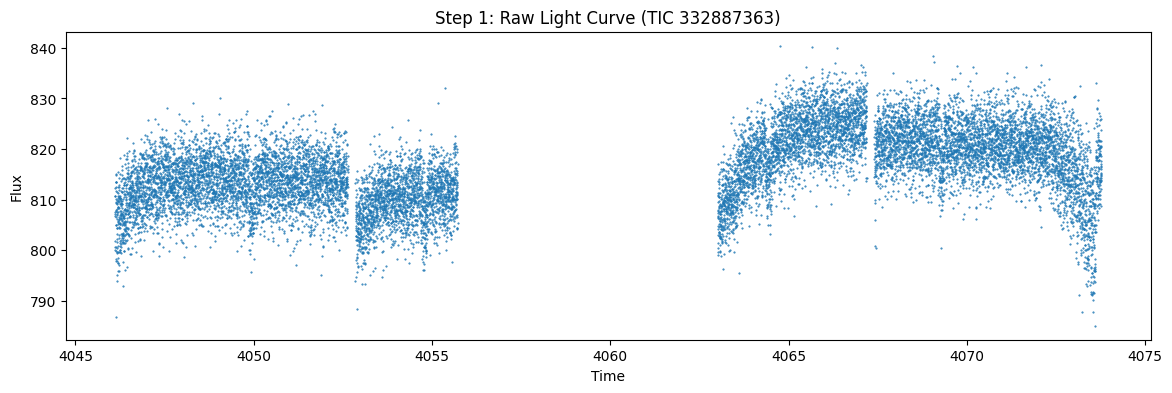

In [34]:
# =========================================================
# Step 1: Raw Light Curve
# =========================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astroquery.mast import Observations

# =========================================================
# Step 0: 下载 TESS 光变曲线（替代 URI）
# =========================================================

def download_tess_lc(tic):

    obs = Observations.query_criteria(
        objectname=f"TIC {tic}",
        dataproduct_type="timeseries",
        obs_collection="TESS"
    )

    products = Observations.get_product_list(obs)

    lc = Observations.filter_products(
        products,
        productSubGroupDescription=["LIGHTCURVE", "LC", "SAP_FLUX", "PDCSAP_FLUX"]
    )


    manifest = Observations.download_products(lc)

    return manifest


# =========================================================
# Step 1: 选择目标 TIC 并下载
# =========================================================

tic = 332887363

manifest = download_tess_lc(tic)

# 下载后的文件路径（自动生成）
local_path = manifest['Local Path'][0]


# =========================================================
# Step 2: 读取 FITS（和你原来完全一样）
# =========================================================

hdul = fits.open(local_path)
data = hdul[1].data

time = data['TIME'].astype(np.float64)
flux = data['SAP_FLUX'].astype(np.float64)

mask = np.isfinite(time) & np.isfinite(flux)
time = time[mask]
flux = flux[mask]

# =========================================================
# Step 3: 画图（完全不变）
# =========================================================

plt.figure(figsize=(14,4))
plt.plot(time, flux, '.', markersize=1)
plt.title(f"Step 1: Raw Light Curve (TIC {tic})")
plt.xlabel("Time")
plt.ylabel("Flux")
plt.savefig("figures2/step1_raw.png", dpi=300, bbox_inches='tight')
plt.show()

hdul.close()

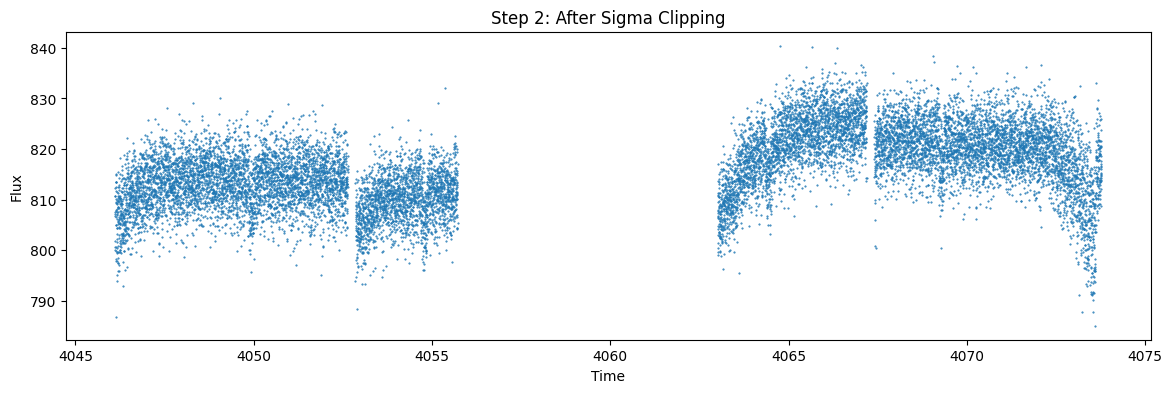

In [35]:
# =========================================================
# Step 2: Sigma Clipping 
# =========================================================

flux_clip = sigma_clip(flux, sigma=5, maxiters=3)
mask = ~flux_clip.mask

time = time[mask]
flux = flux[mask]

plt.figure(figsize=(14,4))
plt.plot(time, flux, '.', markersize=1)
plt.title("Step 2: After Sigma Clipping")
plt.xlabel("Time")
plt.ylabel("Flux")
plt.savefig("figures2/step2_clip.png", dpi=300, bbox_inches='tight')
plt.show()


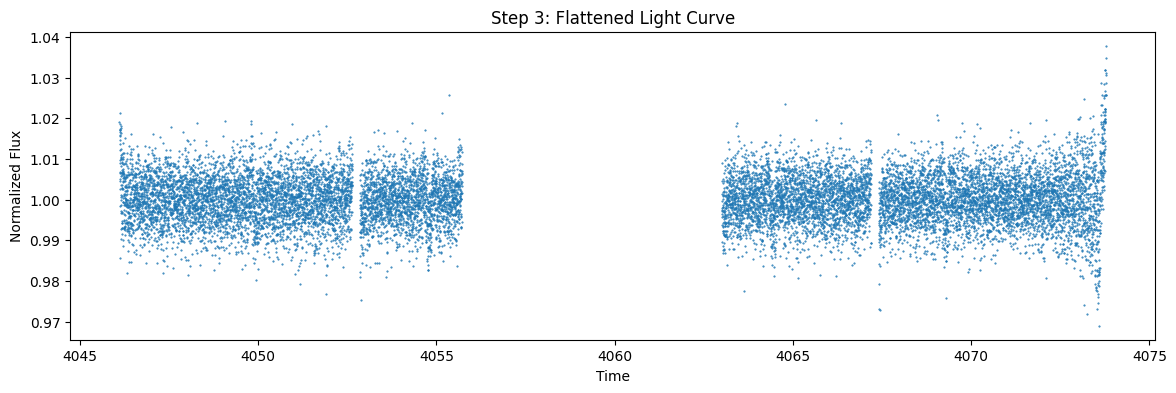

In [36]:
# =========================================================
# Step 3: Detrending
# =========================================================

trend = medfilt(flux, kernel_size=301)
flux_flat = flux / trend

plt.figure(figsize=(14,4))
plt.plot(time, flux_flat, '.', markersize=1)
plt.title("Step 3: Flattened Light Curve")
plt.xlabel("Time")
plt.ylabel("Normalized Flux")
plt.savefig("figures2/step3_flat.png", dpi=300, bbox_inches='tight')
plt.show()


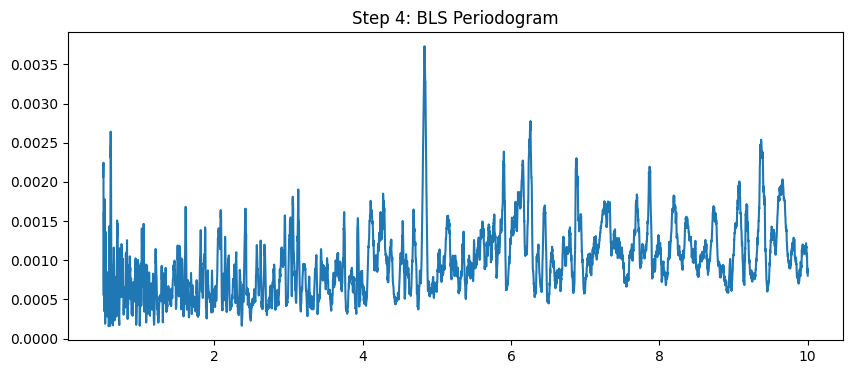

4.8328665733146625 4049.937078646456 0.16


In [37]:
# =========================================================
# Step 4: BLS Period Search
# =========================================================

bls = BoxLeastSquares(time, flux_flat)

periods = np.linspace(0.5, 10, 5000)
durations = np.linspace(0.05, 0.3, 10)

result = bls.power(periods, durations)

best_idx = np.argmax(result.power)

P = result.period[best_idx]
t0 = result.transit_time[best_idx]
Tdur = result.duration[best_idx]

plt.figure(figsize=(10,4))
plt.plot(result.period, result.power)
plt.title("Step 4: BLS Periodogram")
plt.savefig("figures2/step4_bls.png", dpi=300, bbox_inches='tight')
plt.show()

print(P, t0, Tdur)

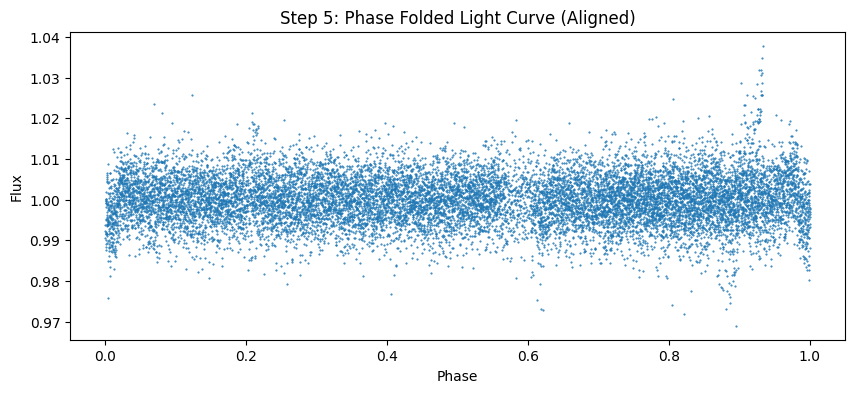

In [38]:
# =========================================================
# Step 5: Phase Folding 
# =========================================================

phase = ((time - t0) / P) % 1

plt.figure(figsize=(10,4))
plt.plot(phase, flux_flat, '.', markersize=1)
plt.title("Step 5: Phase Folded Light Curve (Aligned)")
plt.xlabel("Phase")
plt.ylabel("Flux")
plt.savefig("figures2/step5_phase.png", dpi=300, bbox_inches='tight')
plt.show()

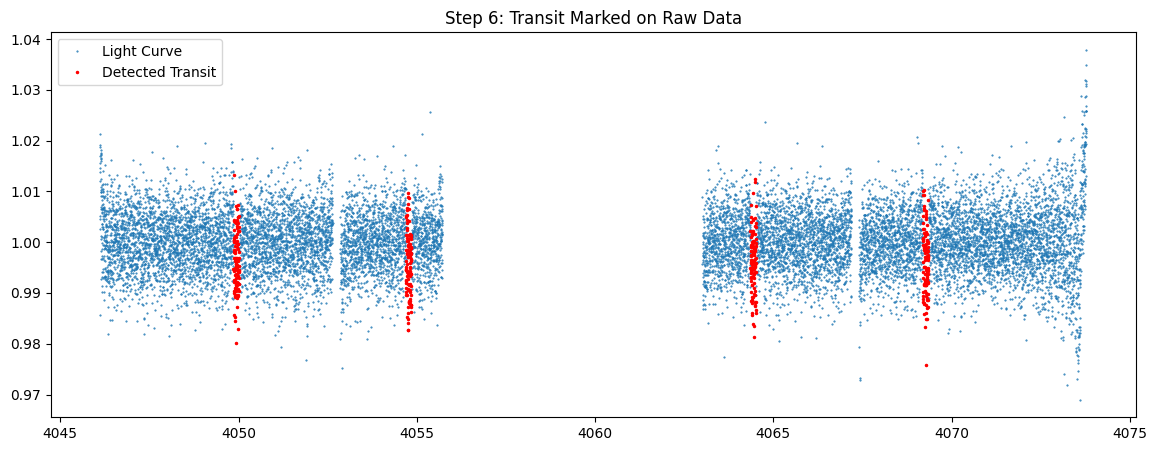

In [39]:
# =========================================================
# Step 6: Model-based Transit Reconstruction
# =========================================================

in_transit = bls.transit_mask(time, P, Tdur, t0)

plt.figure(figsize=(14,5))

plt.plot(time, flux_flat, '.', markersize=1, label="Light Curve")

plt.plot(
    time[in_transit],
    flux_flat[in_transit],
    'r.',
    markersize=3,
    label="Detected Transit"
)

plt.title("Step 6: Transit Marked on Raw Data")
plt.legend()
plt.savefig("figures2/step6_transit.png", dpi=300, bbox_inches='tight')
plt.show()